# 熱量

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# pdfフォルダを作成
output_dir = Path("pdf")
output_dir.mkdir(exist_ok=True)

# フォントサイズを大きく設定
plt.rcParams["font.size"] = 20
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["axes.labelsize"] = 22
plt.rcParams["legend.fontsize"] = 18
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18

files = [
    ("heatSource_to_heatSink",
     "postProcessing/heatSource/qInt_heatSource_to_heatSink/0/surfaceFieldValue.dat"),
    ("heatSink_to_heatSource",
     "postProcessing/heatSink/qInt_heatSink_to_heatSource/0/surfaceFieldValue.dat"),
]

plt.figure(figsize=(12, 8))

for label, file in files:
    df = pd.read_csv(
        file,
        comment="#",
        sep=r"\s+",
        header=None,
        names=["Time", "Q"],
        engine="python"
    )
    plt.plot(df["Time"], np.abs(df["Q"]), label=label, linewidth=2.5)

plt.xlabel("Time [s]")
plt.ylabel("Heat flow [W]")
plt.title("Heat flow history across heatSource-heatSink interface")
plt.grid(True)
plt.legend()
plt.tight_layout()

# PDF保存
plt.savefig(output_dir / "heatflow_history_interface.pdf", bbox_inches="tight")

# PNGも必要なら保存
plt.savefig("heatflow_history_interface.png", dpi=300, bbox_inches="tight")

plt.show()

# 温度

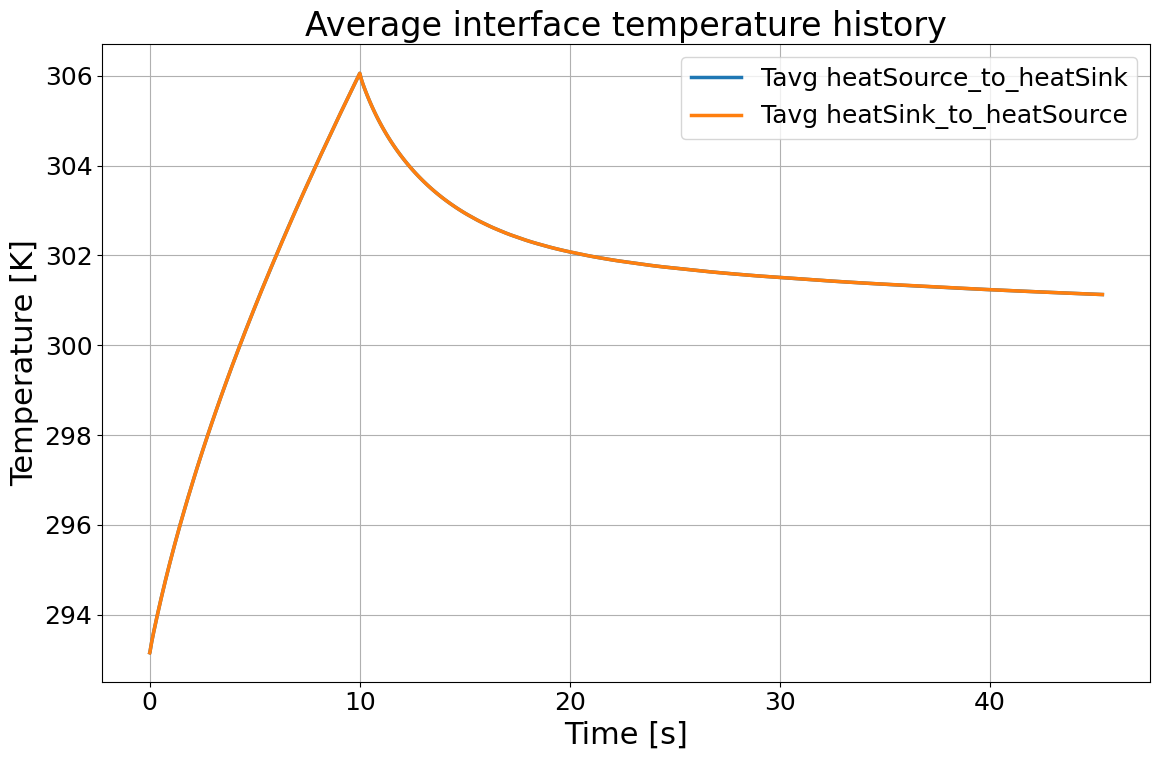

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# pdfフォルダを作成
output_dir = Path("pdf")
output_dir.mkdir(exist_ok=True)

# フォントサイズを大きく設定
plt.rcParams["font.size"] = 20
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["axes.labelsize"] = 22
plt.rcParams["legend.fontsize"] = 18
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18

files = [
    ("Tavg heatSource_to_heatSink",
     "postProcessing/heatSource/Tavg_heatSource_to_heatSink/0/surfaceFieldValue.dat"),
    ("Tavg heatSink_to_heatSource",
     "postProcessing/heatSink/Tavg_heatSink_to_heatSource/0/surfaceFieldValue.dat"),
]

plt.figure(figsize=(12, 8))

for label, file in files:
    df = pd.read_csv(
        file,
        comment="#",
        sep=r"\s+",
        header=None,
        names=["Time", "T"],
        engine="python"
    )
    plt.plot(df["Time"], df["T"], label=label, linewidth=2.5)

plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.title("Average interface temperature history")
plt.grid(True)
plt.legend()
plt.tight_layout()

# PDF保存
plt.savefig(output_dir / "average_interface_temperature_history.pdf", bbox_inches="tight")

# PNGも必要なら保存
plt.savefig("average_interface_temperature_history.png", dpi=300, bbox_inches="tight")

plt.show()

# 温度比較（ヒートシンクありなし）

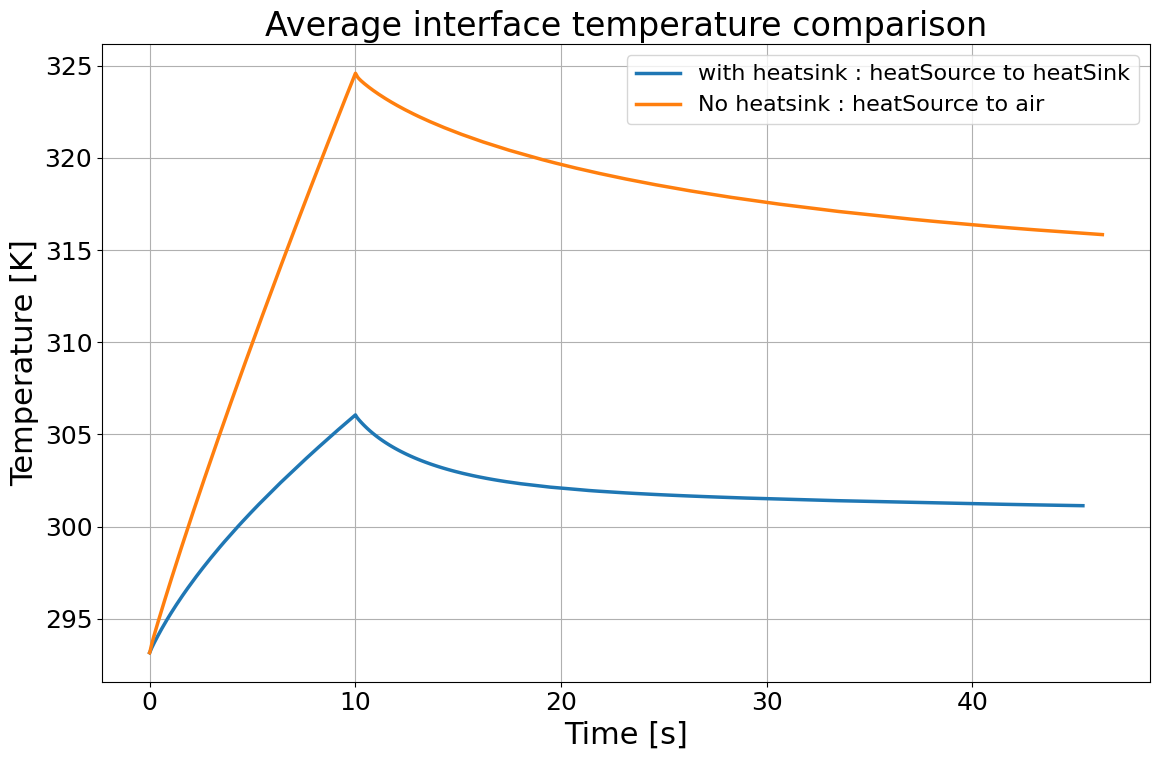

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# pdfフォルダを作成
output_dir = Path("pdf")
output_dir.mkdir(exist_ok=True)

# フォントサイズを大きく設定
plt.rcParams["font.size"] = 20
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["axes.labelsize"] = 22
plt.rcParams["legend.fontsize"] = 16
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18

cases = [
    (
        "with heatsink",
        Path("."),
        [
            (
                "heatSource to heatSink",
                "postProcessing/heatSource/Tavg_heatSource_to_heatSink/0/surfaceFieldValue.dat",
            ),
        ],
    ),
    (
        "No heatsink",
        Path("../ana001_chtMultiRegionFoam_Noheatsink"),
        [
            (
                "heatSource to air",
                "postProcessing/heatSource/Tavg_heatSource_to_air/0/surfaceFieldValue.dat",
            ),
        ],
    ),
]

plt.figure(figsize=(12, 8))

for case_label, case_dir, files in cases:
    for label, rel_file in files:
        file = case_dir / rel_file

        df = pd.read_csv(
            file,
            comment="#",
            sep=r"\s+",
            header=None,
            names=["Time", "T"],
            engine="python",
        )

        plt.plot(
            df["Time"],
            df["T"],
            label=f"{case_label} : {label}",
            linewidth=2.5,
        )

plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.title("Average interface temperature comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(output_dir / "average_interface_temperature_comparison.pdf", bbox_inches="tight")
plt.savefig("average_interface_temperature_comparison.png", dpi=300, bbox_inches="tight")

plt.show()